# Titanic Survival Prediction

## Problem Overview

On April 15, 1912, the RMS Titanic sank after hitting an iceberg. 1502 out of 2224 passengers and crew died. The question Kaggle asks is: **given information about a passenger, predict whether they survived or not.**

This is a **binary classification problem** — output is either 0 (died) or 1 (survived).

## Dataset

The data is based on real passenger records, split by Kaggle into:

- `train.csv` — 891 passengers where the answer is known (Survived column is present). Used to train the model.
- `test.csv` — 418 passengers where Survived is hidden. We predict it.
- `gender_submission.csv` — a sample of what the submission file should look like.

## Column Descriptions

| Column | Description |
|--------|-------------|
| PassengerId | Row number, no predictive value |
| Survived | 0 = died, 1 = survived (target variable) |
| Pclass | Ticket class: 1 = First, 2 = Second, 3 = Third (proxy for wealth) |
| Name | Full name — contains useful titles (Mr, Mrs, Miss, Master) |
| Sex | male or female — women were prioritized in lifeboats |
| Age | Age in years — children were also prioritized |
| SibSp | Number of siblings/spouses aboard |
| Parch | Number of parents/children aboard |
| Ticket | Ticket number — mostly noise |
| Fare | Amount paid — correlates with Pclass and wealth |
| Cabin | Cabin number — 77% missing, but whether someone had one matters |
| Embarked | Port of embarkation: S = Southampton, C = Cherbourg, Q = Queenstown |

## 1. Load Data & Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape, test.shape)
print(train.head())
print(train.isnull().sum())

(891, 12) (418, 11)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500

## 2. Exploratory Data Analysis (EDA)

Before building any model, we visualize the data to understand which features drive survival. Key findings:

- **Women survived at much higher rates** — "women and children first" evacuation policy
- **3rd class had the worst survival** — lower decks meant longer path to lifeboats
- **Children under 10 had higher survival rates** — raw counts by age group are misleading; survival *rate* for young children was higher
- **Fare and Pclass are negatively correlated** — wealthier passengers paid more and survived more

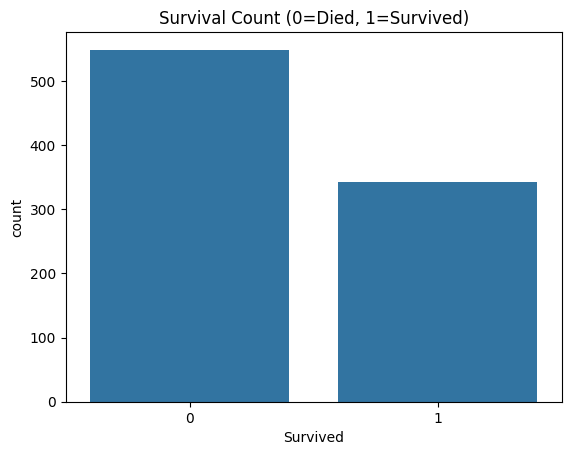

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [2]:
# Survival distribution
sns.countplot(x='Survived', data=train)
plt.title('Survival Count (0=Died, 1=Survived)')
plt.show()

print(train['Survived'].value_counts(normalize=True))

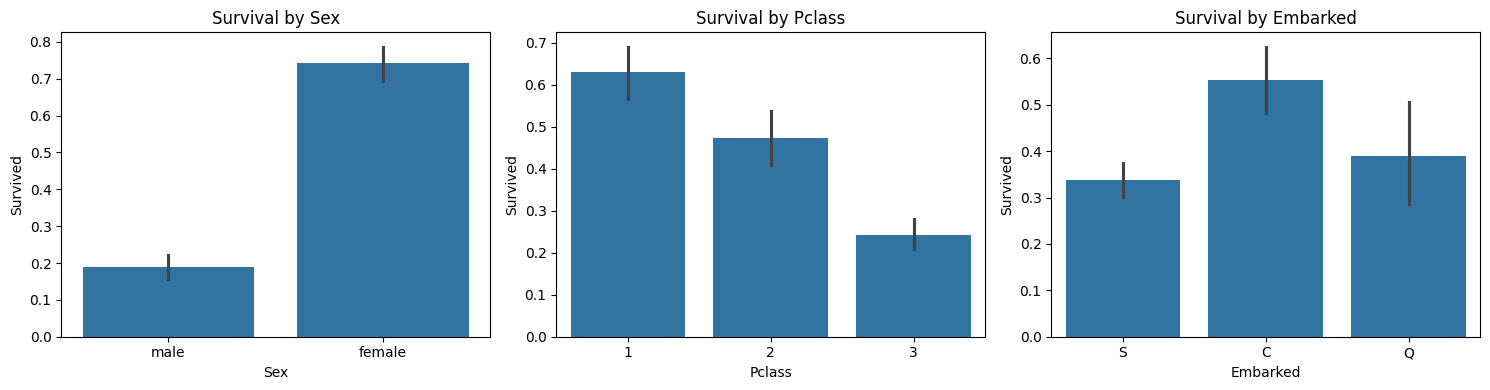

In [3]:
# Survival by key categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(x='Sex', y='Survived', data=train, ax=axes[0])
axes[0].set_title('Survival by Sex')

sns.barplot(x='Pclass', y='Survived', data=train, ax=axes[1])
axes[1].set_title('Survival by Pclass')

sns.barplot(x='Embarked', y='Survived', data=train, ax=axes[2])
axes[2].set_title('Survival by Embarked')

plt.tight_layout()
plt.show()

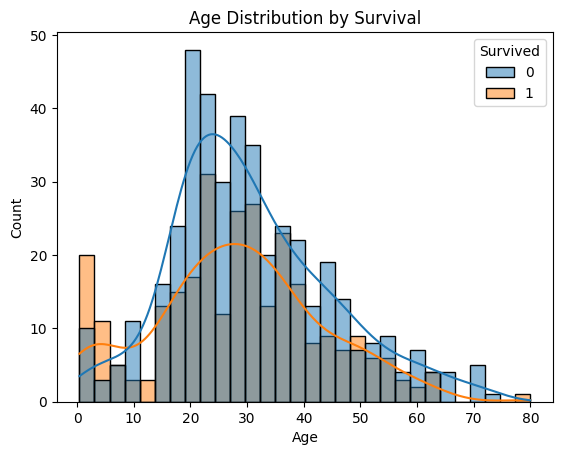

In [4]:
# Age distribution by survival
sns.histplot(data=train, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Age Distribution by Survival')
plt.show()

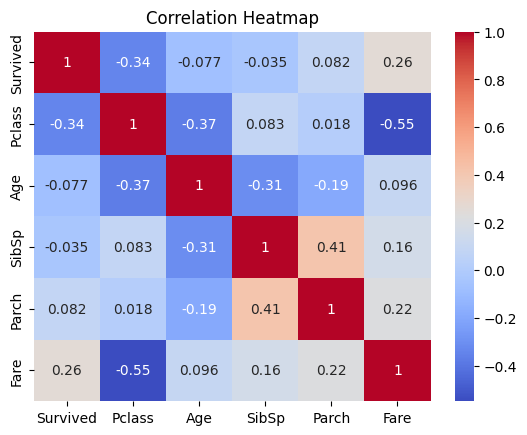

In [5]:
# Correlation heatmap
sns.heatmap(train[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 3. Feature Engineering

Raw features alone don't capture the full picture. Engineering new features that better represent the underlying patterns:

- **Title** — extracted from Name. Acts as a proxy for age, gender, and social status simultaneously. `Master` = young boy, `Mrs` = married woman, `Rare` = high-status titles. Since Age had 177 missing values but Name had zero, Title also lets us fill Age more intelligently.
- **FamilySize** — SibSp + Parch + 1. Solo travelers vs. families behaved differently in the evacuation.
- **IsAlone** — binary flag from FamilySize.
- **Has_Cabin** — whether a cabin record exists. Since 77% is missing, we can't use the value directly, but *having* a cabin (i.e., being wealthier) is informative.
- **Age imputation** — filled using median grouped by Title and Pclass, not a global median. A Master in 3rd class gets a different age estimate than a Mr in 1st class.

In [6]:
# Combine train and test for consistent feature engineering
train['dataset'] = 'train'
test['dataset'] = 'test'

combined = pd.concat([train, test], ignore_index=True)
print(combined.shape)

(1309, 13)


In [7]:
# Fix missing Embarked (2 rows) and Fare (1 row in test)
combined['Embarked'] = combined['Embarked'].fillna(combined['Embarked'].mode()[0])
combined['Fare'] = combined['Fare'].fillna(combined['Fare'].median())

In [8]:
# Extract Title from Name using regex
combined['Title'] = combined['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(combined['Title'].value_counts())

Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Ms            2
Major         2
Mlle          2
Don           1
Mme           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64


In [9]:
# Clean titles: merge French variants, group rare titles
combined['Title'] = combined['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
combined['Title'] = combined['Title'].replace(
    ['Rev', 'Dr', 'Col', 'Major', 'Don', 'Lady', 'Sir', 'Capt', 'Countess', 'Jonkheer', 'Dona'],
    'Rare'
)

print(combined['Title'].value_counts())

Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64


In [10]:
# Fill missing Age using median grouped by Title and Pclass
# This is smarter than a global median — a Master in 3rd class gets a different estimate
combined['Age'] = combined.groupby(['Title', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

print(combined['Age'].isnull().sum())  # should be 0

0


In [11]:
# Family features
combined['FamilySize'] = combined['SibSp'] + combined['Parch'] + 1
combined['IsAlone'] = (combined['FamilySize'] == 1).astype(int)

print(combined[['FamilySize', 'IsAlone']].head(10))

   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1
5           1        1
6           1        1
7           5        0
8           3        0
9           2        0


In [12]:
# Has_Cabin: whether a cabin record exists at all
combined['Has_Cabin'] = combined['Cabin'].notna().astype(int)
print(combined['Has_Cabin'].value_counts())

Has_Cabin
0    1014
1     295
Name: count, dtype: int64


In [13]:
# Encode categorical features as numbers (required for sklearn models)
combined['Sex'] = combined['Sex'].map({'male': 0, 'female': 1})
combined['Embarked'] = combined['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
combined['Title'] = combined['Title'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4})

print(combined[['Sex', 'Embarked', 'Title']].head())

   Sex  Embarked  Title
0    0         0      0
1    1         1      2
2    1         0      1
3    1         0      2
4    0         0      0


In [14]:
# Drop columns we no longer need
combined.drop(['Name', 'Ticket', 'Cabin', 'dataset'], axis=1, inplace=True)
print(combined.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'Has_Cabin']


In [15]:
# Split back into train and test
train_clean = combined[combined['PassengerId'] <= 891].copy()
test_clean = combined[combined['PassengerId'] > 891].copy()

X = train_clean.drop(['Survived', 'PassengerId'], axis=1)
y = train_clean['Survived']

X_test_final = test_clean.drop(['Survived', 'PassengerId'], axis=1)

print(X.shape, y.shape, X_test_final.shape)

(891, 11) (891,) (418, 11)


## 4. Model Training & Evaluation

training two models and comparing them:

- **Logistic Regression** — baseline linear model. Draws a straight decision boundary. Good for interpretability (you can read off coefficients).
- **Random Forest** — ensemble of 100 decision trees. Captures non-linear patterns like "women in 3rd class had lower survival than women in 1st class." Usually outperforms LR on this dataset.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Fill any remaining nulls before splitting
X = X.fillna(X.mode().iloc[0])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression baseline
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)
print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_lr))
print(classification_report(y_val, y_pred_lr))

Logistic Regression Accuracy: 0.7877094972067039
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82       105
         1.0       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

Random Forest Accuracy: 0.8491620111731844
              precision    recall  f1-score   support

         0.0       0.88      0.87      0.87       105
         1.0       0.81      0.82      0.82        74

    accuracy                           0.85       179
   macro avg       0.84      0.85      0.84       179
weighted avg       0.85      0.85      0.85       179



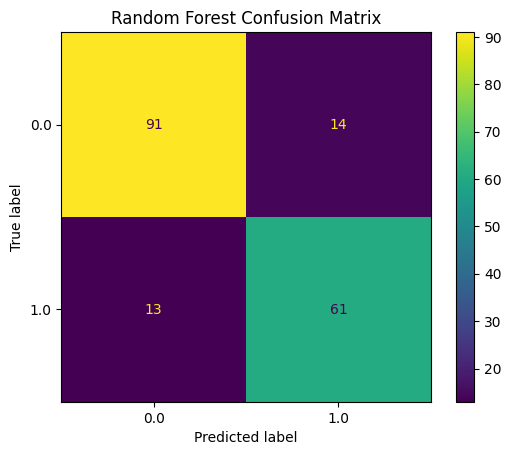

In [18]:
# Confusion Matrix — visual breakdown of correct/incorrect predictions
ConfusionMatrixDisplay.from_estimator(rf, X_val, y_val)
plt.title('Random Forest Confusion Matrix')
plt.show()

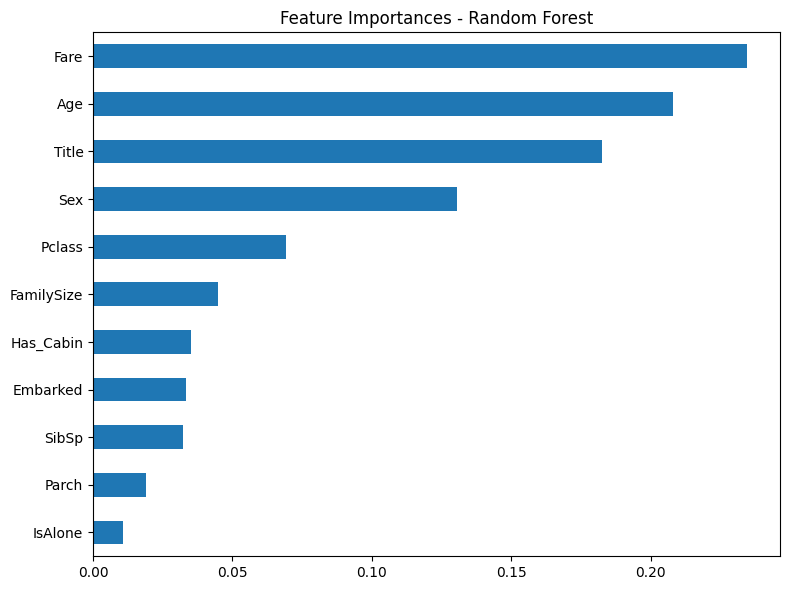

In [19]:
# Feature Importance — what did the model actually learn?
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

## 5. Generate Predictions

Random Forest to predict on test data.

In [20]:
# Fill any nulls in test data (same strategy)
X_test_final = X_test_final.fillna(X_test_final.mode().iloc[0])

predictions = rf.predict(X_test_final)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': predictions.astype(int)
})

submission.to_csv('submission.csv', index=False)
print(submission.head(10))
print("Submission saved.")

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0
Submission saved.


## 6. Summary

### Results

| Model | Validation Accuracy |
|-------|--------------------|
| Logistic Regression | 79% |
| Random Forest | 85% |

Random Forest outperforms Logistic Regression because survival patterns are non-linear — a woman in 1st class had a very different survival probability than a woman in 3rd class, which a linear model can't capture well.

### Top Features

The Random Forest learned that **Fare**, **Age**, and **Title** are the most predictive features:

- **Fare** — continuous variable with strong signal; proxies wealth better than Pclass alone
- **Age** — children were prioritized; many useful split points for trees
- **Title** — encodes gender, age group, and social status in one feature; did a lot of work